Found 420 images belonging to 6 classes.


Cargado: ../models/trained/efficientnetb3_20251023-122312.h5


Cargado: ../models/trained/mobilenetv2_20251022-144833.h5


Cargado: ../models/trained/resnet50_20251022-141919.h5
Cargado: ../models/trained/vgg16_20251022-144302.h5


2025-10-23 12:30:46.868986: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-10-23 12:30:47.000457: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-10-23 12:30:47.132988: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-10-23 12:30:47.263535: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-10-23 12:30:47.638368: E external/local_xla/xla/stream_

              precision    recall  f1-score   support

   cardboard       1.00      0.72      0.83        60
       glass       0.78      0.53      0.63        75
       metal       0.79      0.43      0.55        61
       paper       0.84      0.71      0.77        89
     plastic       0.36      0.94      0.52        72
       trash       0.93      0.40      0.56        63

    accuracy                           0.63       420
   macro avg       0.78      0.62      0.64       420
weighted avg       0.78      0.63      0.65       420



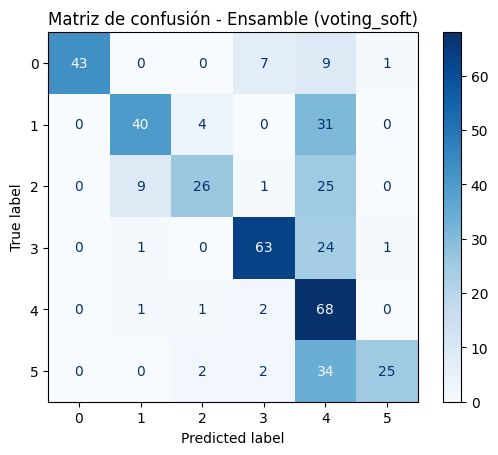

In [34]:
# 1. Imports
import numpy as np
import sys
import os

# Añadir la carpeta donde está ensemble.py al PATH
sys.path.append(os.path.abspath("../models"))

from ensemble import load_models, build_generators, predict_ensemble
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


# 2. Cargar los modelos y el generador de validación
model_paths = [
    "../models/trained/efficientnetb3_20251023-122312.h5",
    "../models/trained/mobilenetv2_20251022-144833.h5",
    "../models/trained/resnet50_20251022-141919.h5",
    "../models/trained/vgg16_20251022-144302.h5",
]

# La carpeta real con split está en data/processed/garbage_classification_split
val_gen = build_generators("../data/processed/garbage_classification_split")

models = load_models(model_paths)

# 3. Predicciones del ensamble
y_true = val_gen.classes
y_pred = predict_ensemble(models, val_gen, method="voting_soft")

# 4. Métricas
# Asegurarse de pasar una lista de nombres en el orden correcto
class_names = [k for k, v in sorted(val_gen.class_indices.items(), key=lambda x: x[1])]
print(classification_report(y_true, y_pred, target_names=class_names))
cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm).plot(cmap='Blues')
plt.title("Matriz de confusión - Ensamble (voting_soft)")
plt.show()


In [28]:
# Helper: wrapper para predecir una imagen y mitigar retracing de TF
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import numpy as np
import os

# Reducir el ruido de logging de TF (INFO/WARNING) en la salida
tf.get_logger().setLevel('ERROR')

def build_predict_functions(models):
    """Construye una lista de funciones tf.function que llaman a cada modelo una vez (reduce retracing)."""
    predict_fns = []
    for name, m in models:
        # Creamos una función trazada por modelo; fijamos _m como default arg para evitar cierre sobre la variable mutable
        @tf.function
        def fn(x, _m=m):
            # asegurarse de devolver logits/probs como tensor
            return _m(x, training=False)
        predict_fns.append((name, fn))
    return predict_fns

def predict_image(img_path, models, val_gen, img_size=(224,224)):
    """Carga una imagen, obtiene predicción por cada modelo y devuelve voting_soft (promedio de probabilidades)."""
    if not os.path.exists(img_path):
        raise FileNotFoundError(f'No se encuentra la imagen: {img_path}')
    if len(models) == 0:
        raise ValueError('No hay modelos cargados en la variable `models`. Ejecuta la celda que carga los modelos primero.')

    # cargar y preprocesar
    img = image.load_img(img_path, target_size=tuple(img_size))
    arr = image.img_to_array(img) / 255.0
    arr = np.expand_dims(arr, axis=0)
    tensor = tf.convert_to_tensor(arr, dtype=tf.float32)

    # Construir funciones de predicción (trazadas) una vez
    predict_fns = build_predict_functions(models)
    preds = []
    for name, fn in predict_fns:
        p = fn(tensor).numpy()
        if p.ndim == 2 and p.shape[0] == 1:
            p = p[0]
        else:
            p = np.ravel(p)
        preds.append(p)

    all_preds = np.array(preds)  # (n_models, n_classes)
    avg = np.mean(all_preds, axis=0)
    class_names = [k for k, v in sorted(val_gen.class_indices.items(), key=lambda x: x[1])]
    class_idx = int(np.argmax(avg))
    class_name = class_names[class_idx]
    return { 'class_idx': class_idx, 'class_name': class_name, 'probs': {cn: float(p) for cn, p in zip(class_names, avg)} }

# Ejemplo de uso:
# resultado = predict_image('a.jpg', models, val_gen)
# print(resultado)


In [29]:
# Celda de ejemplo: llamar a predict_image y mostrar resultado (manejo de errores)
try:
    resultado = predict_image('a.jpg', models, val_gen)
    print('Resultado:', resultado)
except Exception as e:
    print('Error en predict_image:', e)


Error en predict_image: No se encuentra la imagen: a.jpg
